# 04. LightGBM — Gradient Boosting

**Goal:** Train a LightGBM classifier, the industry-standard algorithm for tabular data. 
Compare performance against Logistic Regression and Random Forest to evaluate whether 
gradient boosting captures patterns the simpler models missed.

**Why LightGBM over XGBoost / CatBoost:**
- Fastest training via histogram-based algorithm and leaf-wise tree growth
- Memory efficient — handles datasets that don't fit into XGBoost
- Strong default regularization (early stopping is native)
- Industry standard for Kaggle competitions and production ML on tabular data

**Key algorithmic difference from Random Forest:**
- **Boosting (sequential):** each tree corrects errors of previous trees
- **Built-in regularization:** learning rate, L1/L2 on leaf weights, early stopping
- **Leaf-wise growth:** grows the most promising leaf (not level-by-level like XGBoost)

**Preprocessing:** No feature scaling needed (tree-based model).


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [2]:
df = pd.read_csv('../data/raw/high_diamond_ranked_10min.csv')
print(f'Dataset frame: {df.shape}')
df.info()

Dataset frame: (9879, 40)
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   i

In [3]:
# From 03_random_forest.ipynb we'll take the same preprocessing tools: drop columns and train_test_split

columns_to_drop = [
    # Identifier
    'gameId',
    
    # Definitional duplicates (blue's kill = red's death)
    'redKills',      # = blueDeaths
    'redDeaths',     # = blueKills
    
    # Deterministic complement
    'redFirstBlood', # = 1 - blueFirstBlood
    
    # Linear transforms (GPM = TotalGold / 10)
    'blueGoldPerMin',
    'redGoldPerMin',
    
    # CS duplicates
    'blueCSPerMin',  # = blueTotalMinionsKilled / 10
    'redCSPerMin',
    
    # Mirror diffs (same info with sign flip)
    'redGoldDiff',        # = -blueGoldDiff
    'redExperienceDiff',  # = -blueExperienceDiff
    
    # Aggregates (keep detail, drop sum)
    'blueEliteMonsters',  # = blueDragons + blueHeralds
    'redEliteMonsters',
]

df_copy = df.copy()
df_copy = df_copy.drop(columns=columns_to_drop)
df_copy.shape

(9879, 28)

In [4]:
X = df_copy.drop(columns=['blueWins'])
y = df_copy['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size = 0.2,
                                                   stratify=y,
                                                   random_state=42)

print(f'x_train shape: {X_train.shape}')
print(f'x_test shape: {X_test.shape}')
print(f'Class balance in train: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Class balance in test: {y_test.value_counts(normalize=True).to_dict()}')

x_train shape: (7903, 27)
x_test shape: (1976, 27)
Class balance in train: {0: 0.500949006706314, 1: 0.49905099329368596}
Class balance in test: {0: 0.5010121457489879, 1: 0.49898785425101216}


## Train / Validation / Test Split

For gradient boosting we need a three-way split:
- **Train fit** — used to build trees
- **Validation** — used for early stopping (model sees it at each iteration)
- **Test** — final unbiased evaluation, not seen during training

This is different from RF and logistic regression, where a two-way train/test split 
was sufficient because they have no iterative training process.

In [5]:
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

print(f'X_train_fit: {X_train_fit.shape}')
print(f'X_val: {X_val.shape}')
print(f'X_test: {X_test.shape}')

X_train_fit: (6322, 27)
X_val: (1581, 27)
X_test: (1976, 27)


In [6]:
model = LGBMClassifier(
    random_state=42,
    n_estimators=500,
    verbosity=-1,
)

model.fit(X_train_fit, y_train_fit,
         eval_set=[(X_val, y_val)],
         eval_metric='auc',
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)],)

print(f'\nBest iteration: {model.best_iteration_}')
print(f'Best AUC on validation: {model.best_score_["valid_0"]["auc"]:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid_0's auc: 0.802197	valid_0's binary_logloss: 0.575497

Best iteration: 8
Best AUC on validation: 0.8022


In [7]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Train predictions (для overfit диагностики)
y_pred_train = model.predict(X_train_fit)
y_pred_proba_train = model.predict_proba(X_train_fit)[:, 1]

train_accuracy = accuracy_score(y_train_fit, y_pred_train)
train_roc_auc = roc_auc_score(y_train_fit, y_pred_proba_train)
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f'TRAIN Accuracy: {train_accuracy:.4f}')
print(f'TRAIN ROC-AUC:  {train_roc_auc:.4f}')
print(f'TEST Accuracy:  {test_accuracy:.4f}')
print(f'TEST ROC-AUC:   {test_roc_auc:.4f}')
print(f'TEST F1:        {f1:.4f}')
print(f'Gap ROC-AUC:    {train_roc_auc - test_roc_auc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Blue Loses', 'Blue Wins']))

TRAIN Accuracy: 0.7714
TRAIN ROC-AUC:  0.8445
TEST Accuracy:  0.7146
TEST ROC-AUC:   0.7986
TEST F1:        0.7078
Gap ROC-AUC:    0.0459

Classification Report:
              precision    recall  f1-score   support

  Blue Loses       0.71      0.74      0.72       990
   Blue Wins       0.72      0.69      0.71       986

    accuracy                           0.71      1976
   macro avg       0.71      0.71      0.71      1976
weighted avg       0.71      0.71      0.71      1976



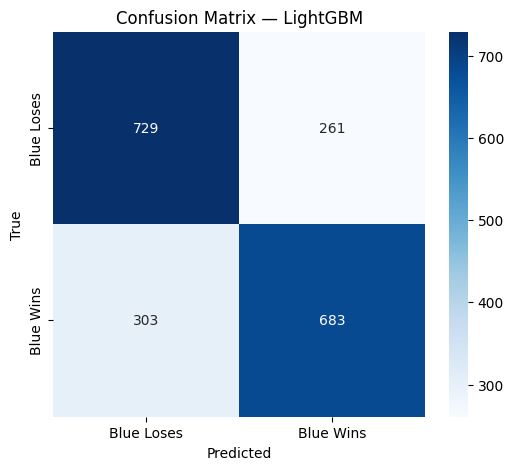

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Blue Loses', 'Blue Wins'],
           yticklabels=['Blue Loses', 'Blue Wins'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — LightGBM')
plt.show()

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_roc_auc_lgbm = cross_val_score(
    LGBMClassifier(random_state=42, n_estimators=500, verbosity=-1,),
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
)
print(f'CV ROC-AUC (LGBM default): {cv_roc_auc_lgbm.mean():.4f} ± {cv_roc_auc_lgbm.std():.4f}')

CV ROC-AUC (LGBM default): 0.7786 ± 0.0099


### Two Types of Feature Importance in LightGBM

- **Split importance** — how often each feature was used to split a node
- **Gain importance** — total reduction in loss achieved by all splits on that feature

**Gain is usually more meaningful** because a feature used 100 times with tiny gains 
can score high on split but low on gain. Gain shows real predictive value.

In [9]:
# Split-based:
importance_split = pd.DataFrame({
    'feature': X_train_fit.columns,
    'importance': model.booster_.feature_importance(importance_type='split'),
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Gain-based: 
importance_gain = pd.DataFrame({
    'feature': X_train_fit.columns,
    'importance': model.booster_.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 by SPLIT (how often used):')
print(importance_split.head(10))
print('\nTop 10 by GAIN (total impact on loss):')
print(importance_gain.head(10))

Top 10 by SPLIT (how often used):
                       feature  importance
0                 blueGoldDiff          55
1           blueExperienceDiff          23
2          blueTotalExperience          17
3                   redDragons          15
4                  blueDragons          15
5           redTotalExperience          15
6  redTotalJungleMinionsKilled          12
7       blueTotalMinionsKilled          12
8        redTotalMinionsKilled          11
9                 redTotalGold           9

Top 10 by GAIN (total impact on loss):
                       feature   importance
0                 blueGoldDiff  7860.218328
1           blueExperienceDiff   302.130752
2                   redDragons   177.485599
3          blueTotalExperience   158.459469
4                  blueDragons   151.088161
5           redTotalExperience   132.951168
6  redTotalJungleMinionsKilled   106.504840
7       blueTotalMinionsKilled    95.447629
8        redTotalMinionsKilled    84.791689
9            

## Tuning: Smaller Trees, Slower Learning

Default LightGBM stopped at iteration 8 with AUC ~0.80. The sharp early stopping 
suggests the model captures the main linear signal (gold diff) quickly but fails 
to find complex interactions in subsequent iterations.

**Tuning hypothesis:** maybe with more granular learning we can squeeze slight 
improvement from subtle feature interactions.

**Changes:**
- `learning_rate`: 0.1 → 0.01 (finer-grained updates)
- `n_estimators`: 500 → 1000 (compensate for smaller lr, early stopping will pick)
- `num_leaves`: 31 → 15 (prevent over-complex trees on ~6K samples)
- `min_child_samples`: default 20 → 30 (more regularization)
- Added L1/L2 regularization on leaf weights

In [13]:
model_tuned = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=15,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1,
)

model_tuned.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# Метрики
y_pred_tuned = model_tuned.predict(X_test)
y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

y_pred_train_t = model_tuned.predict(X_train_fit)
y_pred_proba_train_t = model_tuned.predict_proba(X_train_fit)[:, 1]

train_acc_t = accuracy_score(y_train_fit, y_pred_train_t)
train_auc_t = roc_auc_score(y_train_fit, y_pred_proba_train_t)
test_acc_t = accuracy_score(y_test, y_pred_tuned)
test_auc_t = roc_auc_score(y_test, y_pred_proba_tuned)

print(f'Best iteration: {model_tuned.best_iteration_}')
print(f'\n=== Tuned LightGBM ===')
print(f'TRAIN Accuracy: {train_acc_t:.4f}')
print(f'TRAIN ROC-AUC:  {train_auc_t:.4f}')
print(f'TEST Accuracy:  {test_acc_t:.4f}')
print(f'TEST ROC-AUC:   {test_auc_t:.4f}')
print(f'Gap ROC-AUC:    {train_auc_t - test_auc_t:.4f}')

Best iteration: 73

=== Tuned LightGBM ===
TRAIN Accuracy: 0.7510
TRAIN ROC-AUC:  0.8249
TEST Accuracy:  0.7212
TEST ROC-AUC:   0.8020
Gap ROC-AUC:    0.0229


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_roc_auc_lgbm = cross_val_score(
    LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=15,
        min_child_samples=30,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbosity=-1,
    ),
    X_train, y_train,  # используем полный train, без split на val
    cv=cv,
    scoring='roc_auc',
)
print(f'CV ROC-AUC (LGBM tuned): {cv_roc_auc_lgbm.mean():.4f} ± {cv_roc_auc_lgbm.std():.4f}')

CV ROC-AUC (LGBM tuned): 0.8024 ± 0.0082


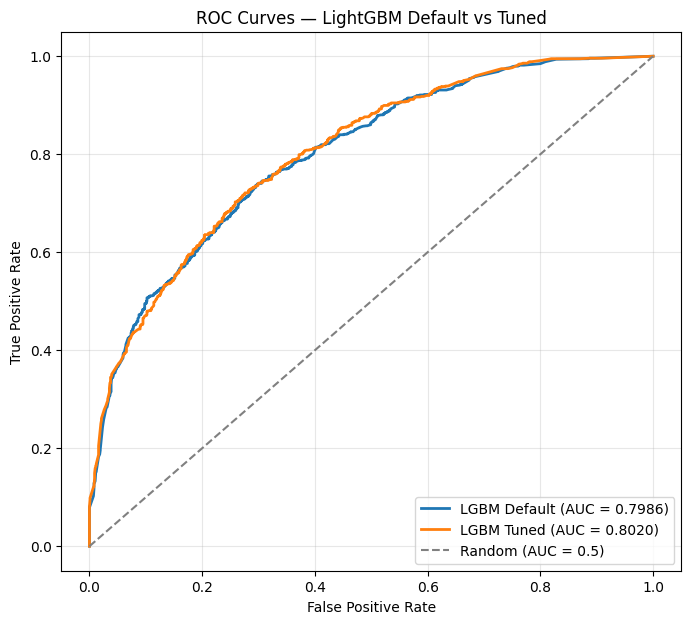

In [16]:
y_pred_proba_default = model.predict_proba(X_test)[:, 1]
y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

fpr_d, tpr_d, _ = roc_curve(y_test, y_pred_proba_default)
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_proba_tuned)

plt.figure(figsize=(8, 7))
plt.plot(fpr_d, tpr_d, label=f'LGBM Default (AUC = {test_roc_auc:.4f})', linewidth=2)
plt.plot(fpr_t, tpr_t, label=f'LGBM Tuned (AUC = {test_auc_t:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'gray', linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — LightGBM Default vs Tuned')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Final Summary

### Model Comparison

| Model | Test Accuracy | Test ROC-AUC | Train-Test Gap | CV ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.7201 | **0.8068** | ~0.01 | 0.8107 ± 0.008 |
| Random Forest (default) | 0.7206 | 0.8006 | 0.20 | 0.7973 ± 0.009 |
| Random Forest (tuned) | 0.7191 | 0.8044 | 0.06 | 0.8066 ± 0.009 |
| LightGBM (default) | 0.7146 | 0.7986 | 0.05 | 0.7786 ± 0.0099 |
| LightGBM (tuned) | 0.7212 | 0.8020 | 0.02 | 0.8024 ± 0.0082 |

### Key Findings

**1. Logistic regression wins this dataset.** Despite trying three fundamentally 
different algorithms (linear, bagging, boosting), all models converge to ~0.80-0.81 
ROC-AUC. The simplest model performs best.

**2. The dataset exhibits an information ceiling around 0.81 ROC-AUC.** This is 
consistent across models and splits, suggesting we've extracted the available signal 
from the current features.

**3. Feature importance confirms single-feature dominance.** `blueGoldDiff` 
outweighs all other features by an order of magnitude across all models. This 
explains why:
- Non-linear methods (RF, LGBM) don't find additional patterns
- LightGBM's default early stopping triggered at iteration 8 — the model 
  captured the main signal quickly and found nothing useful beyond it

**4. Breaking the 0.81 ceiling requires either:**
- **Feature engineering** — derived features like `wards_in_enemy_jungle`, 
  `kills_ratio`, `gold_diff_per_minute` to capture patterns not expressed linearly
- **More data** — more matches across patches and ranks
- **Richer features** — early-game composition data, player skill levels, 
  item timings, not just aggregated stats

### Production Decision

For a production deployment predicting LoL match outcomes from 10-minute data, 
**logistic regression is the optimal choice**:
- Best test performance
- Lowest train-test gap (no overfitting concerns)
- Fastest inference (single linear computation)
- Interpretable coefficients for stakeholders
- No hyperparameters to maintain

This result reflects a broader principle in ML: **model complexity should match 
data complexity**. For relatively linear, feature-sparse datasets, linear models 
are often the right answer.

### Next Steps

1. **Feature engineering** — explore derived features informed by game knowledge
2. **Pipeline productionization** — package logistic regression into a reusable module
3. **Data collection** — more matches, diverse ranks, recent patches for improved generalization